# Step 8 -- 2D Burgers' Equation

The 2D viscous Burgers equation combines nonlinear convection (Step 6) with diffusion (Step 7):

$$
\frac{\partial u}{\partial t}
+ u \frac{\partial u}{\partial x}
+ v \frac{\partial u}{\partial y}
= \nu \left(
  \frac{\partial^2 u}{\partial x^2}
+ \frac{\partial^2 u}{\partial y^2}
\right)
$$

$$
\frac{\partial v}{\partial t}
+ u \frac{\partial v}{\partial x}
+ v \frac{\partial v}{\partial y}
= \nu \left(
  \frac{\partial^2 v}{\partial x^2}
+ \frac{\partial^2 v}{\partial y^2}
\right)
$$

**What you will learn:**

1. How viscosity balances nonlinear steepening
2. The effect of low vs. high viscosity on the solution
3. Differentiating through $\nu$ for parameter sensitivity
4. Why Burgers is the gateway to Navier--Stokes

## Physics

Burgers' equation is the simplest PDE that contains both nonlinear advection and diffusion -- the same two ingredients that appear in the Navier--Stokes momentum equation. Low viscosity allows steep gradients (near-shocks); high viscosity smooths everything out. The balance between these two effects determines the solution character and is controlled by the Reynolds number $\mathrm{Re} = U L / \nu$.

## Grid layout and boundary conditions

In 2D, somax uses the **Arakawa C-grid** where different variables live at different positions within each cell:

```
       V_{j+1/2}
    ┌─────●─────┐
    │           │
 U  ●     T     ●  U
i-1/2   (i,j)    i+1/2
    │           │
    └─────●─────┘
       V_{j-1/2}
```

- **T-points** (cell centres): scalars ($u$, $p$, $\omega$)
- **U-points** (east/west faces): x-fluxes
- **V-points** (north/south faces): y-fluxes
- **X-points** (corners): vorticity (in some formulations)

The full array has shape `(Ny, Nx)` with a **1-cell ghost ring** on all sides:

```
 ┌───────────────────────────────────┐
 │  ghost  ghost  ghost  ghost  ghost│  ← row 0
 │  ghost  T(1,1) T(1,2) ···   ghost│  ← row 1
 │  ghost  T(2,1) T(2,2) ···   ghost│
 │   ⋮      ⋮      ⋮           ⋮    │
 │  ghost  T(n,1) T(n,2) ···   ghost│  ← row Ny-2
 │  ghost  ghost  ghost  ghost  ghost│  ← row Ny-1
 └───────────────────────────────────┘
        col 0  col 1  ···  col Nx-1
```

Interior cells are `[1:-1, 1:-1]`. Ghost cells are filled by boundary conditions before each RHS evaluation.

**Periodic BCs** (`enforce_periodic`) copy the last interior row/column to the opposite ghost row/column. Both `u` and `v` fields receive the same periodic treatment:

```
 field[0, :]  = field[-2, :]   (south ghost ← north interior)
 field[-1, :] = field[1, :]    (north ghost ← south interior)
 field[:, 0]  = field[:, -2]   (west ghost ← east interior)
 field[:, -1] = field[:, 1]    (east ghost ← west interior)
```

In [1]:
from __future__ import annotations

import diffrax as dfx
import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from somax.models import Burgers2D, Burgers2DState

## 1. Create the model

In [2]:
model = Burgers2D.create(nx=64, ny=64, Lx=2.0, Ly=2.0, nu=0.05)
print(model)
print(f"Grid: Nx={model.grid.Nx}, Ny={model.grid.Ny}")
print(f"Spacing: dx={model.grid.dx:.4f}, dy={model.grid.dy:.4f}")

Burgers2D(
  params=Burgers2DParams(nu=weak_f32[]),
  grid=ArakawaCGrid2D(Nx=66, Ny=66, Lx=2.0, Ly=2.0, dx=0.03125, dy=0.03125),
  diff=Difference2D(
    grid=ArakawaCGrid2D(Nx=66, Ny=66, Lx=2.0, Ly=2.0, dx=0.03125, dy=0.03125)
  ),
  advection=Advection2D(
    grid=ArakawaCGrid2D(Nx=66, Ny=66, Lx=2.0, Ly=2.0, dx=0.03125, dy=0.03125),
    recon=Reconstruction2D(
      grid=ArakawaCGrid2D(Nx=66, Ny=66, Lx=2.0, Ly=2.0, dx=0.03125, dy=0.03125)
    )
  ),
  interp=Interpolation2D(
    grid=ArakawaCGrid2D(Nx=66, Ny=66, Lx=2.0, Ly=2.0, dx=0.03125, dy=0.03125)
  )
)
Grid: Nx=66, Ny=66
Spacing: dx=0.0312, dy=0.0312


## 2. Initial condition

A 2D Gaussian for both velocity components.

In [3]:
x = jnp.arange(model.grid.Nx) * model.grid.dx
y = jnp.arange(model.grid.Ny) * model.grid.dy
X, Y = jnp.meshgrid(x, y)

sigma0 = 0.2
gauss = jnp.exp(-0.5 * (((X - 1.0) / sigma0) ** 2 + ((Y - 1.0) / sigma0) ** 2))
u0 = gauss
v0 = gauss

state0 = Burgers2DState(u=u0, v=v0)
print(f"State shapes: u={state0.u.shape}, v={state0.v.shape}")

State shapes: u=(66, 66), v=(66, 66)


## 3. Run the simulation

In [4]:
dt = 0.002
t_final = 0.5
ts = jnp.arange(0.0, t_final, dt)

sol = model.integrate(
    state0,
    t0=0.0,
    t1=t_final,
    dt=dt,
    saveat=dfx.SaveAt(ts=ts),
)

print(f"Solution shapes: u={sol.ys.u.shape}, v={sol.ys.v.shape}")

Solution shapes: u=(250, 66, 66), v=(250, 66, 66)


## 4. Visualize initial and final fields

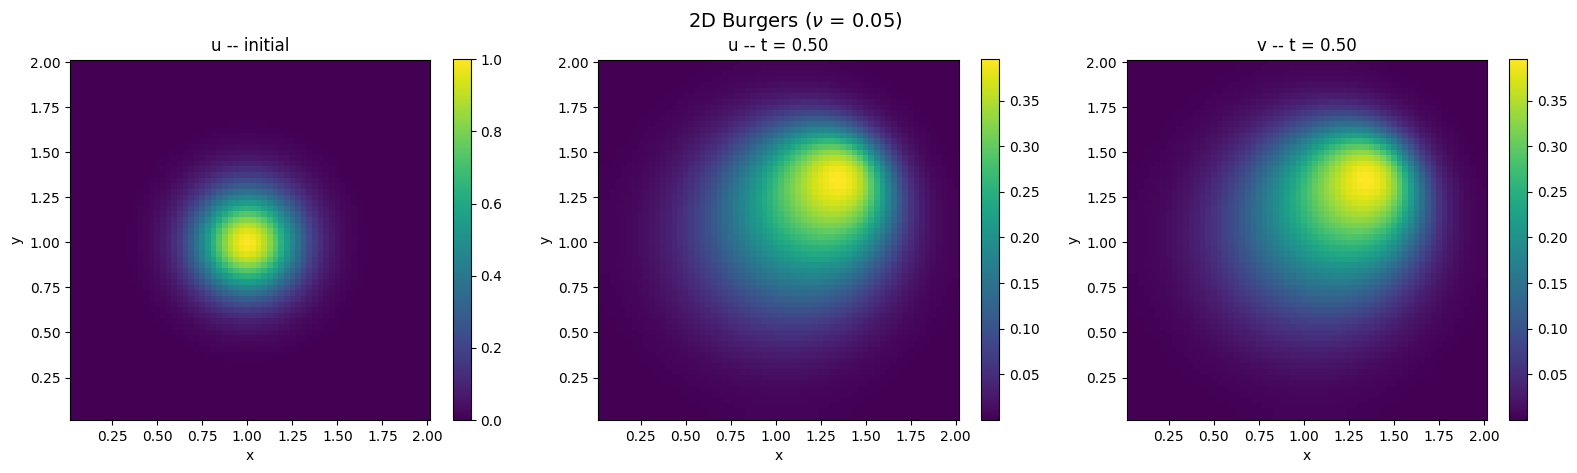

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

pcm0 = axes[0].pcolormesh(
    X[1:-1, 1:-1],
    Y[1:-1, 1:-1],
    sol.ys.u[0, 1:-1, 1:-1],
    shading="auto",
    cmap="viridis",
)
plt.colorbar(pcm0, ax=axes[0])
axes[0].set_title("u -- initial")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_aspect("equal")

pcm1 = axes[1].pcolormesh(
    X[1:-1, 1:-1],
    Y[1:-1, 1:-1],
    sol.ys.u[-1, 1:-1, 1:-1],
    shading="auto",
    cmap="viridis",
)
plt.colorbar(pcm1, ax=axes[1])
axes[1].set_title(f"u -- t = {float(ts[-1]):.2f}")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_aspect("equal")

pcm2 = axes[2].pcolormesh(
    X[1:-1, 1:-1],
    Y[1:-1, 1:-1],
    sol.ys.v[-1, 1:-1, 1:-1],
    shading="auto",
    cmap="viridis",
)
plt.colorbar(pcm2, ax=axes[2])
axes[2].set_title(f"v -- t = {float(ts[-1]):.2f}")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
axes[2].set_aspect("equal")

plt.suptitle(r"2D Burgers ($\nu$ = 0.05)", fontsize=14)
plt.tight_layout()
plt.show()

## 5. Low vs. high viscosity

We run two simulations with different viscosities from the same initial condition and compare the final fields.

In [6]:
nu_low, nu_high = 0.01, 0.2

model_low = Burgers2D.create(nx=64, ny=64, Lx=2.0, Ly=2.0, nu=nu_low)
model_high = Burgers2D.create(nx=64, ny=64, Lx=2.0, Ly=2.0, nu=nu_high)

sol_low = model_low.integrate(
    state0,
    t0=0.0,
    t1=t_final,
    dt=dt,
    saveat=dfx.SaveAt(t1=True),
)
sol_high = model_high.integrate(
    state0,
    t0=0.0,
    t1=t_final,
    dt=dt,
    saveat=dfx.SaveAt(t1=True),
)

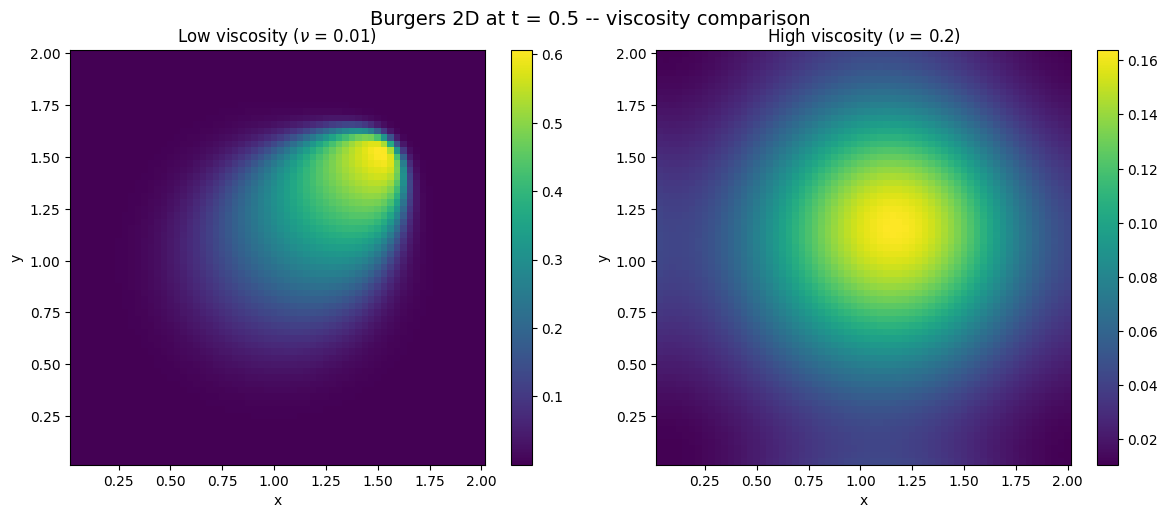

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

pcm0 = axes[0].pcolormesh(
    X[1:-1, 1:-1],
    Y[1:-1, 1:-1],
    sol_low.ys.u[0, 1:-1, 1:-1],
    shading="auto",
    cmap="viridis",
)
plt.colorbar(pcm0, ax=axes[0])
axes[0].set_title(rf"Low viscosity ($\nu$ = {nu_low})")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_aspect("equal")

pcm1 = axes[1].pcolormesh(
    X[1:-1, 1:-1],
    Y[1:-1, 1:-1],
    sol_high.ys.u[0, 1:-1, 1:-1],
    shading="auto",
    cmap="viridis",
)
plt.colorbar(pcm1, ax=axes[1])
axes[1].set_title(rf"High viscosity ($\nu$ = {nu_high})")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_aspect("equal")

plt.suptitle(f"Burgers 2D at t = {t_final} -- viscosity comparison", fontsize=14)
plt.tight_layout()
plt.show()

Low viscosity preserves sharper gradients (the nonlinear steepening from Step 6 dominates). High viscosity smears the solution out (the diffusion from Step 7 dominates).

## 6. Cross-section comparison

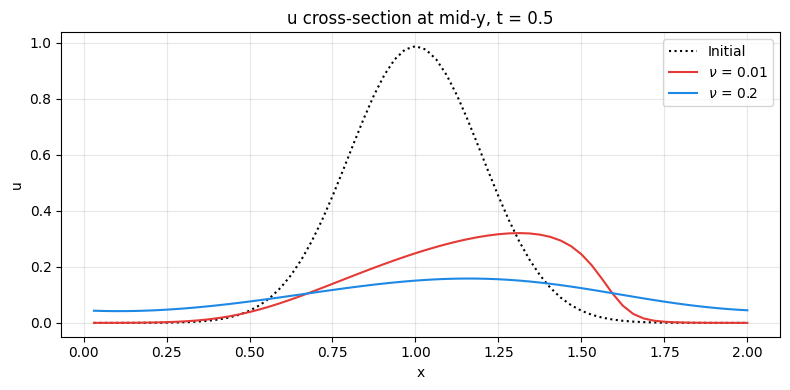

In [8]:
mid_y = model.grid.Ny // 2

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x[1:-1], u0[mid_y, 1:-1], label="Initial", lw=1.5, color="black", ls=":")
ax.plot(
    x[1:-1],
    sol_low.ys.u[0, mid_y, 1:-1],
    label=rf"$\nu$ = {nu_low}",
    lw=1.5,
    color="#E53935",
)
ax.plot(
    x[1:-1],
    sol_high.ys.u[0, mid_y, 1:-1],
    label=rf"$\nu$ = {nu_high}",
    lw=1.5,
    color="#1E88E5",
)
ax.set_xlabel("x")
ax.set_ylabel("u")
ax.set_title(f"u cross-section at mid-y, t = {t_final}")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Gradient through viscosity

We compute $\partial \mathcal{L} / \partial \nu$ where $\mathcal{L} = \sum (u^2 + v^2)$. This tells us how the total kinetic energy depends on viscosity -- useful for calibrating sub-grid diffusion.

In [9]:
@eqx.filter_grad
def grad_nu(m):
    sol = m.integrate(state0, t0=0.0, t1=0.3, dt=0.002)
    return jnp.sum(sol.ys.u**2 + sol.ys.v**2)


grads = grad_nu(model)

print("--- Gradient w.r.t. viscosity ---")
print(f"  dL/d(nu) = {grads.params.nu:.6f}")

--- Gradient w.r.t. viscosity ---


  dL/d(nu) = -1006.128723


## 8. Joint gradient -- viscosity and initial state

In [10]:
def loss_joint(s0, m):
    sol = m.integrate(s0, t0=0.0, t1=0.3, dt=0.002)
    return jnp.sum(sol.ys.u**2 + sol.ys.v**2)


grads_s0, grads_m = jax.grad(loss_joint, argnums=(0, 1))(state0, model)

print("--- Joint gradient ---")
print(f"  max |dL/du0| = {float(jnp.max(jnp.abs(grads_s0.u))):.6f}")
print(f"  max |dL/dv0| = {float(jnp.max(jnp.abs(grads_s0.v))):.6f}")
print(f"  dL/d(nu)     = {grads_m.params.nu:.6f}")

--- Joint gradient ---
  max |dL/du0| = 0.735805
  max |dL/dv0| = 0.735805
  dL/d(nu)     = -1006.128723


## Summary

| Concept | API |
|---------|-----|
| Create model | `Burgers2D.create(nx=64, ny=64, Lx=2.0, Ly=2.0, nu=0.05)` |
| Two-component state | `Burgers2DState(u=u0, v=v0)` |
| Viscosity comparison | create two models with different `nu` |
| Grad w.r.t. $\nu$ | `eqx.filter_grad(loss)(model)` |
| Joint grad | `jax.grad(loss, argnums=(0, 1))(state0, model)` |

**Where we stand:** Steps 5--8 have covered the fundamental building blocks of fluid dynamics in 2D: linear advection, nonlinear advection, diffusion, and their combination in Burgers' equation. The next steps introduce **elliptic solvers** (Laplace, Poisson) which are needed to enforce incompressibility in the Navier--Stokes equations.